In [52]:
import pandas as pd
import numpy as np
from IPython.core.pylabtools import figsize
from PIL.ImageChops import difference
from matplotlib import pyplot as plt
from scipy.signal.windows import blackman
from scipy.spatial import distance
from statsmodels.graphics.tukeyplot import results
import os
import re
from utils import *

from statsmodels.sandbox.distributions.genpareto import shape

In [11]:
# df_hme1 = pd.read_excel("Experiment/1_hTERT_HME1/Data/Processed/Full_dataset_1_hTERT_HME1_diff.xlsx")
df_hme2 = pd.read_excel("Experiment/1_hTERT_HME1/Data/Processed/Full_dataset_1_hTERT_HME1_functional_names_diff_scaled.xlsx")
# df_hek = pd.read_excel("Experiment/2_hTERT_HME1/Data/Processed/Full_dataset_2_hTERT_HME1_diff.xlsx")

# df_hme1 = df_hme1.fillna(0)
df_hme2 = df_hme2.fillna(0)
# df_hek = df_hek.fillna(0)

 Plot not saved


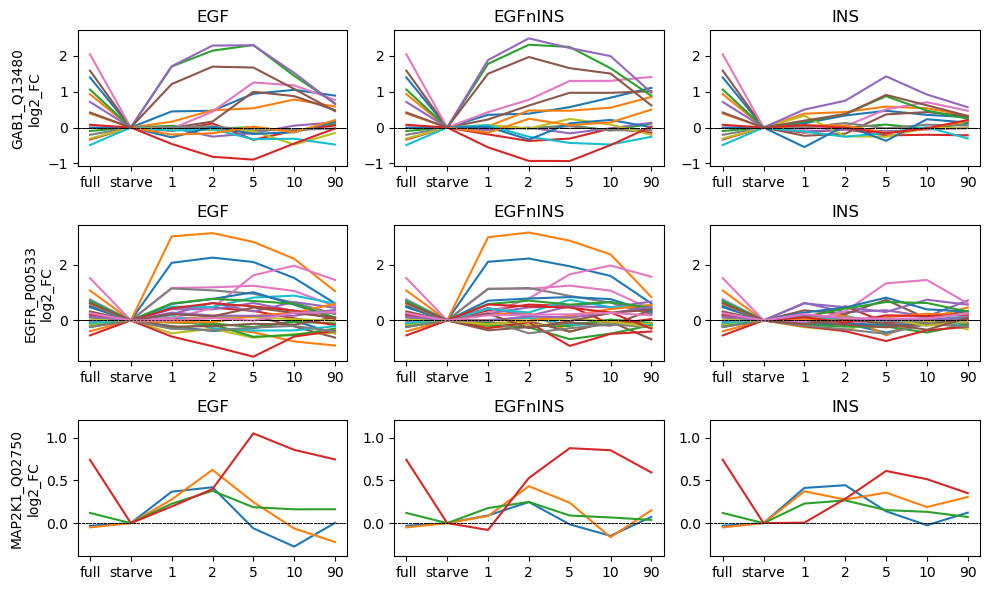

In [36]:
plot_protein_profile(df=df_hme2, experiment="2_hTERT_HME1", data_type= "log2_FC",
                     proteins = ['GAB1', "EGFR", 'MAP2K1'],
                     saving_path= "", saving_info="",
                     legend=False,
                     save_pdf=False, save_png=False)

GAB1_Q13480 Plot not saved


EGFR_P00533 Plot not saved


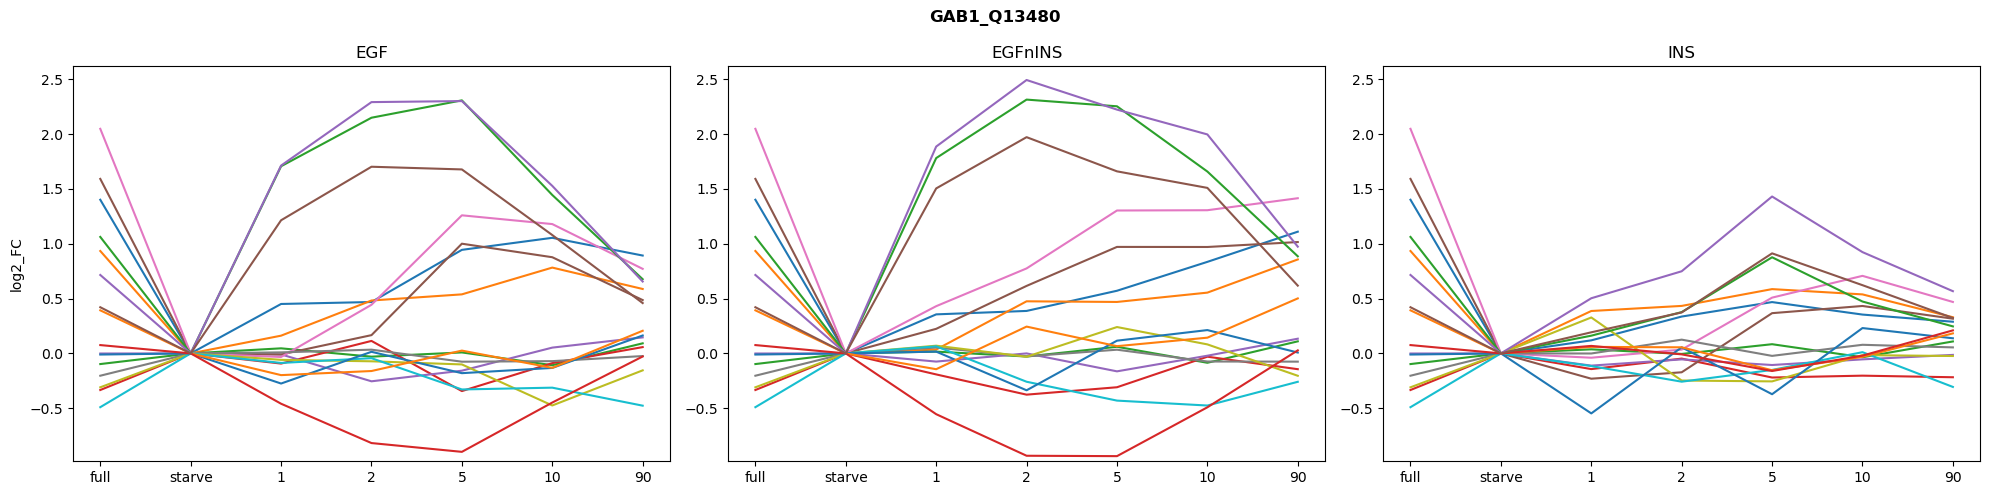

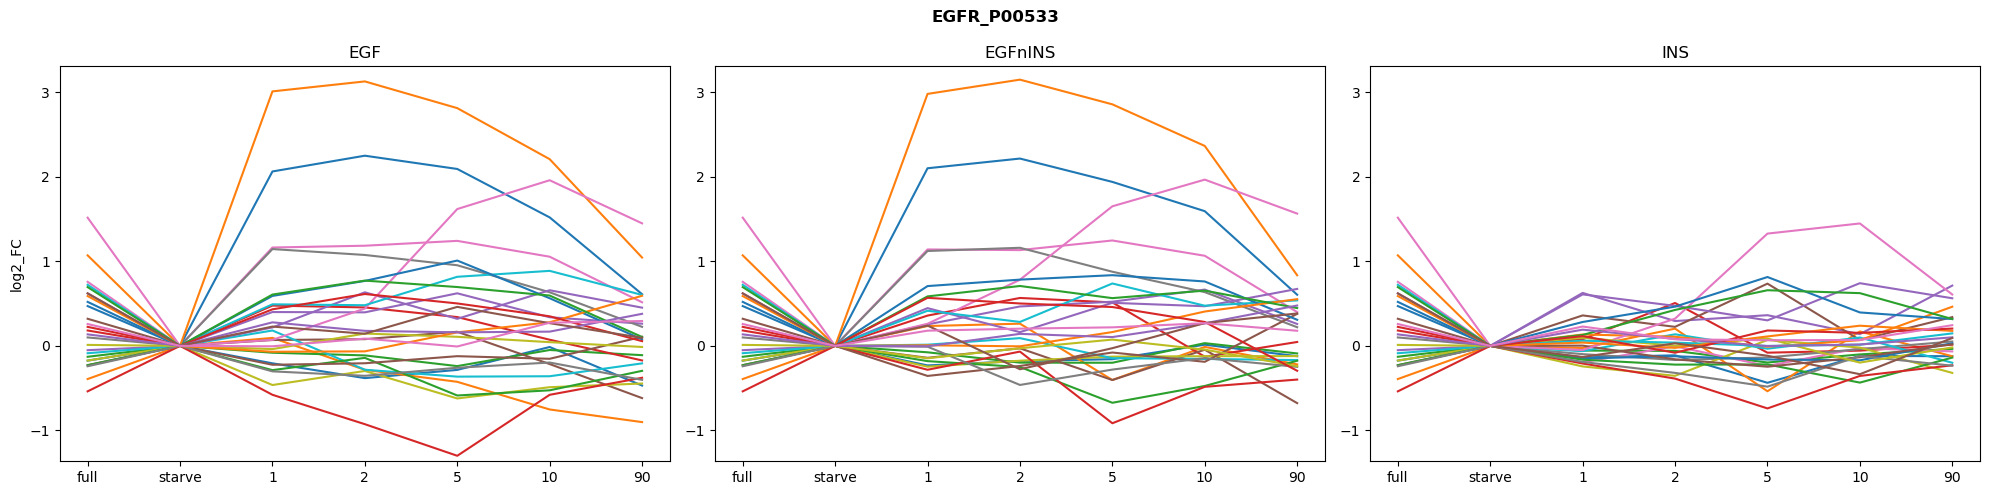

In [51]:
plot_protein_profiles_fine_line(df = df_hme2, proteins = ['GAB1', "EGFR"], data_type= "log2_FC",
                         saving_path = str, legend = False,
                         save_pdf=False, save_png=False)

In [6]:
# #### Calculating means
# dictionary = {}
# for index, row in df.iterrows():
#     EGF = row[["FC_EGF_full", "FC_EGF_starve", "FC_EGF1", "FC_EGF2", "FC_EGF5", "FC_EGF10",  "FC_EGF90"]]
#     INS = row[["FC_INS_full", "FC_INS_starve", "FC_INS1", "FC_INS2", "FC_INS5", "FC_INS10", "FC_INS90"]]
#     EGFnINS = row[["FC_EGFnINS_full", "FC_EGFnINS_starve", "FC_EGFnINS1", "FC_EGFnINS2", "FC_EGFnINS5", "FC_EGFnINS10", "FC_EGFnINS90"]]
#     results = []
#     for i in range(len(EGF)):
#         results.append(INS[i]-EGFnINS[i])
#     sumatory = sum([abs(x) for x in results])
#     dictionary[(row["site"])] = sumatory
#
# keys = list(dictionary.keys())
# values = list(dictionary.values())
# sorted_value_index = np.argsort(values)
# sorted_dict = {keys[i]: values[i] for i in sorted_value_index}
#
# sorted_dict
# keys_sorted = list(sorted_dict.keys())
# values_sorted = list(sorted_dict.values())
#
# diff_df = pd.DataFrame(columns=["site", "difference_INS_EGFnINS" ]) #"protein_Id",
#
# for key in keys_sorted:
#     diff_df.loc[len(diff_df)] = [(key.split("_"))[0],key, sorted_dict[key]]
# diff_df

# #### Calaculating geometric mean for differences
# dictionary = {}
# for index, row in df.iterrows():
#     geometric_mean = np.sqrt(row["difference_EGF_vs_EGFnINS"]*row["difference_INS_vs_EGFnINS"])
#     dictionary[(row["site"])] = geometric_mean
#
# geometric_mean_df = pd.DataFrame(columns=["site", "difference_geometric_mean"])
# for key in dictionary:
#     geometric_mean_df.loc[len(geometric_mean_df)] = [key, dictionary[key]]
# geometric_mean_df

KeyboardInterrupt: 

In [8]:
# #### Calculating means
# data_with_df = pd.merge(df, diff_df, on="site", how="left")
# data_with_df.to_excel("Experiment/1_hTERT_HME1/Data/Processed/Full_dataset_1_hTERT_HME1_diff.xlsx", index = False)
# data_with_df

# #### Calaculating geometric mean for differences
data_with_geometric_mean = pd.merge(df, geometric_mean_df, on="site", how="left")
# data_with_geometric_mean.to_excel("Experiment/1_HEK293T/Data/Processed/Full_dataset_HEK293T_diff.xlsx", index=False)


In [9]:
# data_with_df = pd.read_excel("Experiment/2_hTERT_HME1/Data/Processed/Full_dataset_2_hTERT_HME1_diff.xlsx")
data_with_df = data_with_geometric_mean.copy()


In [10]:

data_with_df_EGF = data_with_df.sort_values(by=["difference_EGF_vs_EGFnINS"], ascending=False)
data_with_df_INS = data_with_df.sort_values(by=["difference_INS_vs_EGFnINS"], ascending=False)
data_with_df_geometric_mean = data_with_df.sort_values(by=["difference_geometric_mean"], ascending=False)
# sites_values = data_with_df.site.values
difference_values_EGF = data_with_df_EGF.difference_EGF_vs_EGFnINS.values
difference_values_INS = data_with_df_INS.difference_INS_vs_EGFnINS.values
difference_values_geometric_mean = data_with_df_geometric_mean.difference_geometric_mean.values

KeyError: 'difference_geometric_mean'

NameError: name 'difference_values_EGF' is not defined

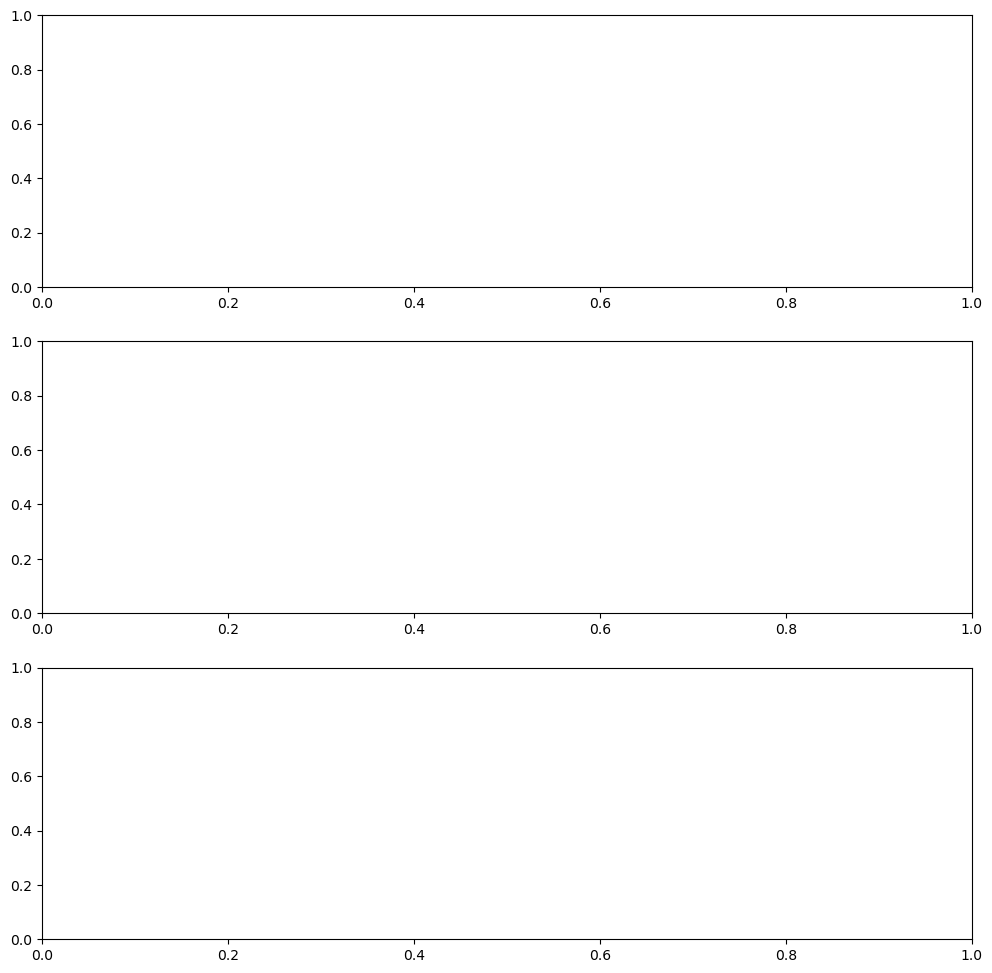

In [11]:
fig, ax = plt.subplots(3, 1, figsize = (12,12))
    
ax[0].bar(range(len(difference_values_EGF)), difference_values_EGF)
ax[0].set_ylabel("Difference between log2FC EGF and EGFnINS")
# ax[0].axhline(value_threshold, color='red', linestyle='--', linewidth=0.5)

ax[1].bar(range(len(difference_values_INS)), difference_values_INS)
ax[1].set_ylabel("Difference between log2FC INS and EGFnINS")
# ax[1].axhline(value_threshold, color='red', linestyle='--', linewidth=0.5)


ax[2].bar(range(len(difference_values_geometric_mean)), difference_values_geometric_mean)
ax[2].set_ylabel("Geometric mean of differences")
# ax[2].axhline(value_threshold, color='red', linestyle='--', linewidth=0.5)

fig.suptitle("1_HEK293T (all dataset, no filtering)", weight='bold')
fig.tight_layout()
# plt.savefig(f".pdf")

In [13]:
subset_df_EGF = data_with_df_EGF.loc[data_with_df_EGF["n_rep"] > 3]
subset_df_INS = data_with_df_INS.loc[data_with_df_INS["n_rep"] > 3]
subset_df_geometric_mean = data_with_df_geometric_mean.loc[data_with_df_geometric_mean["n_rep"] > 3]

print(subset_df_EGF.shape)
subset_df_EGF = subset_df_EGF.sort_values(by=['difference_EGF_vs_EGFnINS'], ascending=False)
subset_df_INS = subset_df_INS.sort_values(by=['difference_INS_vs_EGFnINS'], ascending=False)
subset_df_geometric_mean = subset_df_geometric_mean.sort_values(by=['difference_geometric_mean'], ascending=False)

df_EGF = subset_df_EGF.difference_EGF_vs_EGFnINS.values
df_INS = subset_df_INS.difference_INS_vs_EGFnINS.values
df_geometric_mean = subset_df_geometric_mean.difference_geometric_mean.values

NameError: name 'data_with_df_geometric_mean' is not defined

NameError: name 'df_EGF' is not defined

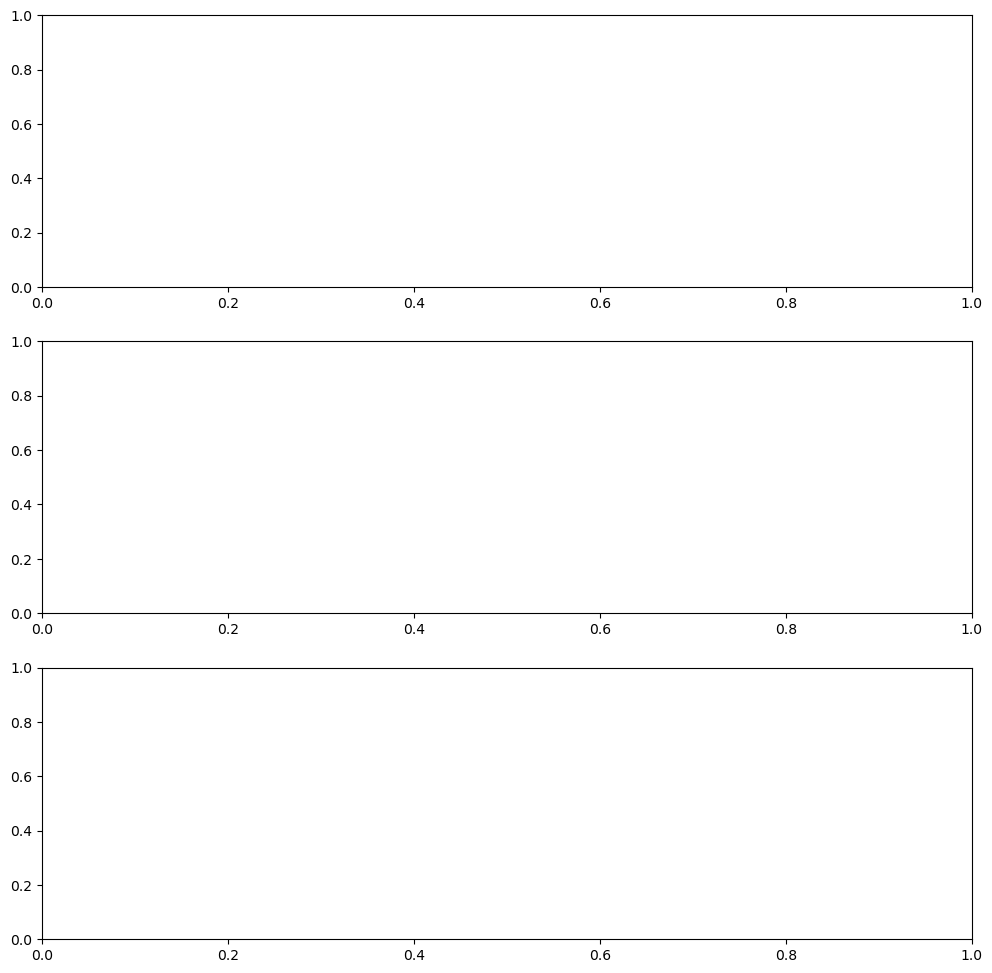

In [14]:

fig, ax = plt.subplots(3, 1, figsize = (12,12))
    
ax[0].bar(range(len(df_EGF)), df_EGF)
ax[0].set_ylabel("Difference between log2FC EGF and EGFnINS")

ax[1].bar(range(len(df_INS)), df_INS)
ax[1].set_ylabel("Difference between log2FC INS and EGFnINS")

ax[2].bar(range(len(df_geometric_mean)), df_geometric_mean)
ax[2].set_ylabel("Geometric mean of differences")

fig.suptitle("1_HEK293T sites with more than 1 replicate", weight='bold')
fig.tight_layout()

# plt.show()

# Check euclidean distances


In [5]:
df = pd.read_excel("Experiment/2_hTERT_HME1/Data/Processed/Full_dataset_2_hTERT_HME1_diff.xlsx")
df = df.fillna(0)
df

,protein_Id,description,protein_name,Peptide,MaxPepProbability,site_start,site_end,n_sites,localized_sites,phospho_sites,...,CV_raw_EGFnINS_starve,CV_raw_EGFnINS2,CV_raw_EGFnINS5,CV_raw_EGFnINS10,CV_raw_EGFnINS15,CV_raw_EGFnINS90,CV_raw_All,difference_EGF_vs_EGFnINS,difference_INS_vs_EGFnINS,difference_geometric_mean
0,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGSGNFGGGR,0.9956,197,199,1,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,33.346090,0.644357,0.274540,0.420597
1,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGsGNFGGGR,1.0000,197,199,1,1,S199,...,18.757996,26.165101,1.230777,12.588830,22.938866,25.170515,50.670048,2.434020,1.123635,1.653768
2,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SKSEsPKEPEQLR,1.0000,2,6,1,1,S6,...,11.127109,2.641531,3.917276,5.877727,6.619161,2.665032,10.012151,0.255705,0.459264,0.342689
3,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,sKsESPK,0.9894,2,6,2,2,S2;S4,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,33.437045,0.277106,0.671679,0.431424
4,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,NQGGYGGSSSSSSYGSGR;NQGGYGGSSSSSSYGSGRRF,1.0000,305,316,1,0,0,...,2.917751,8.674894,9.209089,5.233678,18.339542,5.388291,13.267868,0.295146,0.411714,0.348591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50009,rev_Q5VWT5,0,0,GALMNRRGtHVNtMQIK,0.9898,303,307,2,2,T303;T307,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.475756,0.105879,0.085024,0.094880
50010,rev_Q8N6M0,0,0,LQDEIAKYMCHGDsPIQK,0.9970,135,141,1,1,S141,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.985616,0.139221,0.087091,0.110113
50011,rev_Q96M83,0,0,ERGPtIKK,0.9835,505,505,1,1,T505,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.585989,0.450723,0.196474,0.297582
50012,rev_Q9ULL1,0,0,SSASSSTSGFSVPR,0.9787,1366,1376,2,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.384036,0.196891,0.163787,0.179578


In [43]:

#### Calculating euclidean distance
dictionary = {}
for index, row in df.iterrows():
    EGF = row[["FC_EGF_full", "FC_EGF_starve", "FC_EGF1", "FC_EGF2", "FC_EGF5", "FC_EGF10",  "FC_EGF90"]]
    INS = row[["FC_INS_full", "FC_INS_starve", "FC_INS1", "FC_INS2", "FC_INS5", "FC_INS10", "FC_INS90"]]
    EGFnINS = row[["FC_EGFnINS_full", "FC_EGFnINS_starve", "FC_EGFnINS1", "FC_EGFnINS2", "FC_EGFnINS5", "FC_EGFnINS10", "FC_EGFnINS90"]]

    EGFvsINS
    EGF
    for i in range(len(EGF)):
        results.append(INS[i]-EGFnINS[i])
    sumatory = sum([abs(x) for x in results])
    dictionary[(row["site"])] = sumatory

keys = list(dictionary.keys())
values = list(dictionary.values())
sorted_value_index = np.argsort(values)
sorted_dict = {keys[i]: values[i] for i in sorted_value_index}

sorted_dict
keys_sorted = list(sorted_dict.keys())
values_sorted = list(sorted_dict.values())

diff_df = pd.DataFrame(columns=["site", "difference_INS_EGFnINS" ]) #"protein_Id",

for key in keys_sorted:
    diff_df.loc[len(diff_df)] = [(key.split("_"))[0],key, sorted_dict[key]]
diff_df

# # #### Calaculating geometric mean for differences
# dictionary = {}
# for index, row in df.iterrows():
#     geometric_mean = np.sqrt(row["difference_EGF_vs_EGFnINS"]*row["difference_INS_vs_EGFnINS"])
#     dictionary[(row["site"])] = geometric_mean
#
# geometric_mean_df = pd.DataFrame(columns=["site", "difference_geometric_mean"])
# for key in dictionary:
#     geometric_mean_df.loc[len(geometric_mean_df)] = [key, dictionary[key]]
# geometric_mean_df

KeyError: "['FC_EGF1'] not in index"

In [131]:
df = pd.read_excel("Experiment/2_hTERT_HME1/Data/Processed/Full_dataset_2_hTERT_HME1_diff.xlsx")
df

,protein_Id,description,protein_name,Peptide,MaxPepProbability,site_start,site_end,n_sites,localized_sites,phospho_sites,...,CV_raw_EGFnINS2,CV_raw_EGFnINS5,CV_raw_EGFnINS10,CV_raw_EGFnINS15,CV_raw_EGFnINS90,CV_raw_All,difference_EGF_vs_EGFnINS,difference_INS_vs_EGFnINS,difference_geometric_mean,min_diff
0,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGSGNFGGGR,0.9956,197,199,1,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,33.346090,0.644357,0.274540,0.420597,0.274540
1,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGsGNFGGGR,1.0000,197,199,1,1,S199,...,26.165101,1.230777,12.588830,22.938866,25.170515,50.670048,2.434020,1.123635,1.653768,1.123635
2,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SKSEsPKEPEQLR,1.0000,2,6,1,1,S6,...,2.641531,3.917276,5.877727,6.619161,2.665032,10.012151,0.255705,0.459264,0.342689,0.255705
3,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,sKsESPK,0.9894,2,6,2,2,S2;S4,...,0.000000,0.000000,0.000000,0.000000,0.000000,33.437045,0.277106,0.671679,0.431424,0.277106
4,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,NQGGYGGSSSSSSYGSGR;NQGGYGGSSSSSSYGSGRRF,1.0000,305,316,1,0,0,...,8.674894,9.209089,5.233678,18.339542,5.388291,13.267868,0.295146,0.411714,0.348591,0.295146
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50009,rev_Q5VWT5,0,0,GALMNRRGtHVNtMQIK,0.9898,303,307,2,2,T303;T307,...,0.000000,0.000000,0.000000,0.000000,0.000000,9.475756,0.105879,0.085024,0.094880,0.085024
50010,rev_Q8N6M0,0,0,LQDEIAKYMCHGDsPIQK,0.9970,135,141,1,1,S141,...,0.000000,0.000000,0.000000,0.000000,0.000000,11.985616,0.139221,0.087091,0.110113,0.087091
50011,rev_Q96M83,0,0,ERGPtIKK,0.9835,505,505,1,1,T505,...,0.000000,0.000000,0.000000,0.000000,0.000000,21.585989,0.450723,0.196474,0.297582,0.196474
50012,rev_Q9ULL1,0,0,SSASSSTSGFSVPR,0.9787,1366,1376,2,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,14.384036,0.196891,0.163787,0.179578,0.163787


In [57]:
#Checking the max distance of the minimun distance
dictionary ={}

for index, row in df.iterrows():
    if row["difference_INS_vs_EGFnINS"] > row["difference_EGF_vs_EGFnINS"]:
        dictionary[(row["site"])] = row["difference_EGF_vs_EGFnINS"]
    else:
        dictionary[(row["site"])] = row["difference_INS_vs_EGFnINS"]

min_diff_df = pd.DataFrame(columns=["site", "min_diff"])

for key in dictionary:
    min_diff_df.loc[len(min_diff_df)] = [key, dictionary[key]]

# #### merging df
data_with_min_diff = pd.merge(df, min_diff_df, on="site", how="left")
data_with_min_diff

,protein_Id,description,protein_name,Peptide,MaxPepProbability,site_start,site_end,n_sites,localized_sites,phospho_sites,...,CV_raw_EGFnINS2,CV_raw_EGFnINS5,CV_raw_EGFnINS10,CV_raw_EGFnINS15,CV_raw_EGFnINS90,CV_raw_All,difference_EGF_vs_EGFnINS,difference_INS_vs_EGFnINS,difference_geometric_mean,min_diff
0,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGSGNFGGGR,0.9010,197,199,1,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,34.276581,0.211143,0.080023,0.129986,0.080023
1,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGsGNFGGGR,1.0000,197,199,1,1,S199,...,47.666831,4.714165,4.992779,17.848973,14.589706,36.264607,0.627212,0.875666,0.741099,0.627212
2,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,GGGGYGGSGDGYNGFGNDGSNFGGGGSYNDFGNYNNQSSNFGPMK,1.0000,237,271,1,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,5.667786,0.040935,0.039200,0.040058,0.039200
3,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,GGGGYGGSGDGyNGFGNDGSNFGGGGSYNDFGNYNNQSSNFGPMK,1.0000,237,271,1,1,Y244,...,0.000000,0.000000,0.000000,0.000000,0.000000,7.484990,0.130758,0.107351,0.118478,0.107351
4,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,NQGGYGGSSSSSSYGSGR;NQGGYGGSSSSSSYGSGRRF,1.0000,305,316,1,0,0,...,43.313762,5.630183,10.228770,17.900240,10.319898,14.330464,0.326720,0.307026,0.316720,0.307026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36574,rev_Q96JQ0,0,0,AGAGGPGEARVtLARWPPGAEFDLPR,0.9976,1894,1894,1,1,T1894,...,0.000000,0.000000,0.000000,0.000000,0.000000,18.959657,0.228274,0.150927,0.185614,0.150927
36575,rev_Q9HB15,0,0,sRRPPPR,0.9873,419,419,1,1,S419,...,0.000000,0.000000,0.000000,0.000000,0.000000,22.980237,0.385817,0.465041,0.423581,0.385817
36576,rev_Q9UJW3,0,0,VANQLsGGHVDPITVPEMELFRsAVDLDEK,0.9969,72,89,2,2,S72;S89,...,0.000000,0.000000,0.000000,0.000000,0.000000,18.165544,0.102486,0.135095,0.117666,0.102486
36577,rev_Q9UKR3,0,0,TGACLMNDTIKGPyVQR,0.9834,73,86,1,1,Y86,...,0.000000,0.000000,0.000000,0.000000,0.000000,18.677344,0.108641,0.253646,0.166001,0.108641


In [58]:
# data_with_min_diff.to_excel("Experiment/1_HEK293T/Data/Processed/Full_dataset_HEK293T_diff.xlsx", index = False)

In [132]:
# Calculating the total protein score of change under co-stimulation
prot_list = list(df.protein_Id.unique())

protein_score_df = pd.DataFrame(columns=["protein_Id", "protein_total_diff"])
for protein in prot_list:
    total_score = sum(df[df["protein_Id"] == protein]["min_diff"])
    protein_score_df.loc[len(protein_score_df)] = [protein, total_score]
protein_score_df

data_with_protein_score = pd.merge(df, protein_score_df, on="protein_Id", how="left")
data_with_protein_score

,protein_Id,description,protein_name,Peptide,MaxPepProbability,site_start,site_end,n_sites,localized_sites,phospho_sites,...,CV_raw_EGFnINS5,CV_raw_EGFnINS10,CV_raw_EGFnINS15,CV_raw_EGFnINS90,CV_raw_All,difference_EGF_vs_EGFnINS,difference_INS_vs_EGFnINS,difference_geometric_mean,min_diff,protein_total_diff
0,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGSGNFGGGR,0.9956,197,199,1,0,0,...,0.000000,0.000000,0.000000,0.000000,33.346090,0.644357,0.274540,0.420597,0.274540,4.174593
1,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGsGNFGGGR,1.0000,197,199,1,1,S199,...,1.230777,12.588830,22.938866,25.170515,50.670048,2.434020,1.123635,1.653768,1.123635,4.174593
2,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SKSEsPKEPEQLR,1.0000,2,6,1,1,S6,...,3.917276,5.877727,6.619161,2.665032,10.012151,0.255705,0.459264,0.342689,0.255705,4.174593
3,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,sKsESPK,0.9894,2,6,2,2,S2;S4,...,0.000000,0.000000,0.000000,0.000000,33.437045,0.277106,0.671679,0.431424,0.277106,4.174593
4,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,NQGGYGGSSSSSSYGSGR;NQGGYGGSSSSSSYGSGRRF,1.0000,305,316,1,0,0,...,9.209089,5.233678,18.339542,5.388291,13.267868,0.295146,0.411714,0.348591,0.295146,4.174593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50009,rev_Q5VWT5,0,0,GALMNRRGtHVNtMQIK,0.9898,303,307,2,2,T303;T307,...,0.000000,0.000000,0.000000,0.000000,9.475756,0.105879,0.085024,0.094880,0.085024,0.085024
50010,rev_Q8N6M0,0,0,LQDEIAKYMCHGDsPIQK,0.9970,135,141,1,1,S141,...,0.000000,0.000000,0.000000,0.000000,11.985616,0.139221,0.087091,0.110113,0.087091,0.087091
50011,rev_Q96M83,0,0,ERGPtIKK,0.9835,505,505,1,1,T505,...,0.000000,0.000000,0.000000,0.000000,21.585989,0.450723,0.196474,0.297582,0.196474,0.196474
50012,rev_Q9ULL1,0,0,SSASSSTSGFSVPR,0.9787,1366,1376,2,0,0,...,0.000000,0.000000,0.000000,0.000000,14.384036,0.196891,0.163787,0.179578,0.163787,0.319754


In [133]:
# data_with_protein_score.to_excel("Experiment/2_hTERT_HME1/Data/Processed/Full_dataset_2_hTERT_HME1_diff.xlsx", index = False)

# IMPORT HERE THE DATAFRAME WITH DIFFERENCES

In [16]:
kinase_df = pd.read_excel("Experiment/Kinase_list.xlsx")
kinase_list = list(kinase_df.uniprot_id.unique())
# print(kinase_list)

In [17]:
df = pd.read_excel("Experiment/2_hTERT_HME1/Data/Processed/Full_dataset_2_hTERT_HME1_diff.xlsx")
# df = data_with_protein_score.copy()
df_for_kinases = df.loc[df["protein_Id"].isin(kinase_list)]
df_for_kinases

,protein_Id,description,protein_name,Peptide,MaxPepProbability,site_start,site_end,n_sites,localized_sites,phospho_sites,...,CV_raw_EGFnINS5,CV_raw_EGFnINS10,CV_raw_EGFnINS15,CV_raw_EGFnINS90,CV_raw_All,difference_EGF_vs_EGFnINS,difference_INS_vs_EGFnINS,difference_geometric_mean,min_diff,protein_total_diff
460,O00418,Eukaryotic elongation factor 2 kinase OS=Homo ...,EEF2K,LEGVDGGQsPR,1.0000,18,18,1,1,S18,...,12.780940,7.987567,10.087259,17.747744,12.455446,0.416331,0.460038,0.437639,0.416331,7.966625
461,O00418,Eukaryotic elongation factor 2 kinase OS=Homo ...,EEF2K,TLsGSR;TLsGSRPPLLR,0.9991,364,368,1,1,S366,...,24.045737,44.119412,12.466484,17.539517,31.137015,0.929822,2.100905,1.397665,0.929822,7.966625
462,O00418,Eukaryotic elongation factor 2 kinase OS=Homo ...,EEF2K,ESENSGDSGYPsEK;ESENSGDSGYPsEKRGELDDPEPR,1.0000,435,445,1,1,S445,...,38.905272,9.360641,36.469525,17.707580,43.653552,1.296268,1.285560,1.290903,1.285560,7.966625
463,O00418,Eukaryotic elongation factor 2 kinase OS=Homo ...,EEF2K,EHGHsYSNR,1.0000,462,464,1,1,S462,...,5.137655,8.357501,19.178999,17.890270,44.908085,1.883173,1.058193,1.411652,1.058193,7.966625
464,O00418,Eukaryotic elongation factor 2 kinase OS=Homo ...,EEF2K,KYESDEDSLGSSGR,0.9999,468,478,1,0,0,...,0.427159,6.898225,10.426304,28.877064,20.184133,0.847721,0.592504,0.708716,0.592504,7.966625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49663,Q9NWZ3,Interleukin-1 receptor-associated kinase 4 OS=...,IRAK4,TLMTPVQNLEQSYMPPDSSsPENK,1.0000,133,152,1,1,S152,...,0.000000,0.000000,0.000000,0.000000,11.455112,0.089839,0.101036,0.095273,0.089839,0.636287
49851,P45983,Mitogen-activated protein kinase 8 OS=Homo sap...,MAPK8,TAGTSFMMTPYVVTR,0.9445,175,188,1,0,0,...,0.000000,0.000000,0.000000,0.000000,16.942804,0.217640,0.267873,0.241454,0.217640,0.312290
49852,P45983,Mitogen-activated protein kinase 8 OS=Homo sap...,MAPK8,TAGTSFMMtPYVVTR,1.0000,175,188,1,1,T183,...,0.000000,0.000000,0.000000,0.000000,11.841848,0.112156,0.094651,0.103032,0.094651,0.312290
49918,Q8IYT8,Serine/threonine-protein kinase ULK2 OS=Homo s...,ULK2,HLGSSPR,0.9842,581,582,1,0,0,...,0.000000,0.000000,0.000000,0.000000,10.155276,0.154248,0.188791,0.170647,0.154248,0.154248


 Plot not saved


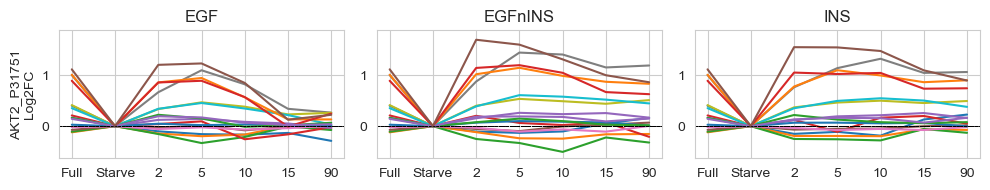

In [182]:
# Protein subset
protein = "GAB1"
protein_subset = df.loc[df['protein_name'] == protein] #, ["protein_Id", 'protein_name', 'site', 'difference_EGF_vs_EGFnINS', 'difference_INS_vs_EGFnINS', "difference_geometric_mean"]]

protein_subset_top = protein_subset.sort_values(by=['min_diff'], ascending=False).head(5)

plot_protein_profile(df=df, experiment="2_hTERT_HME1",
                     proteins = ['AKT2'],
                     saving_path= "", saving_info="",
                     legend="",
                     save_pdf=False, save_png=False)


['UBTF' 'SHTN1' 0 'GAB1' 'BAG3' 'PXN' 'GEMIN8' 'ITPR3' 'CTDSPL2' 'PML'
 'RABL6' 'STAM2' 'HGS' 'PPP1R37' 'IRS1' 'NAA38' 'PLEK2' 'COL17A1' 'KRT1'
 'UBR4' 'FHIP1B' 'PRRC2C' 'ARPP19' 'CIC']


 Plot not saved


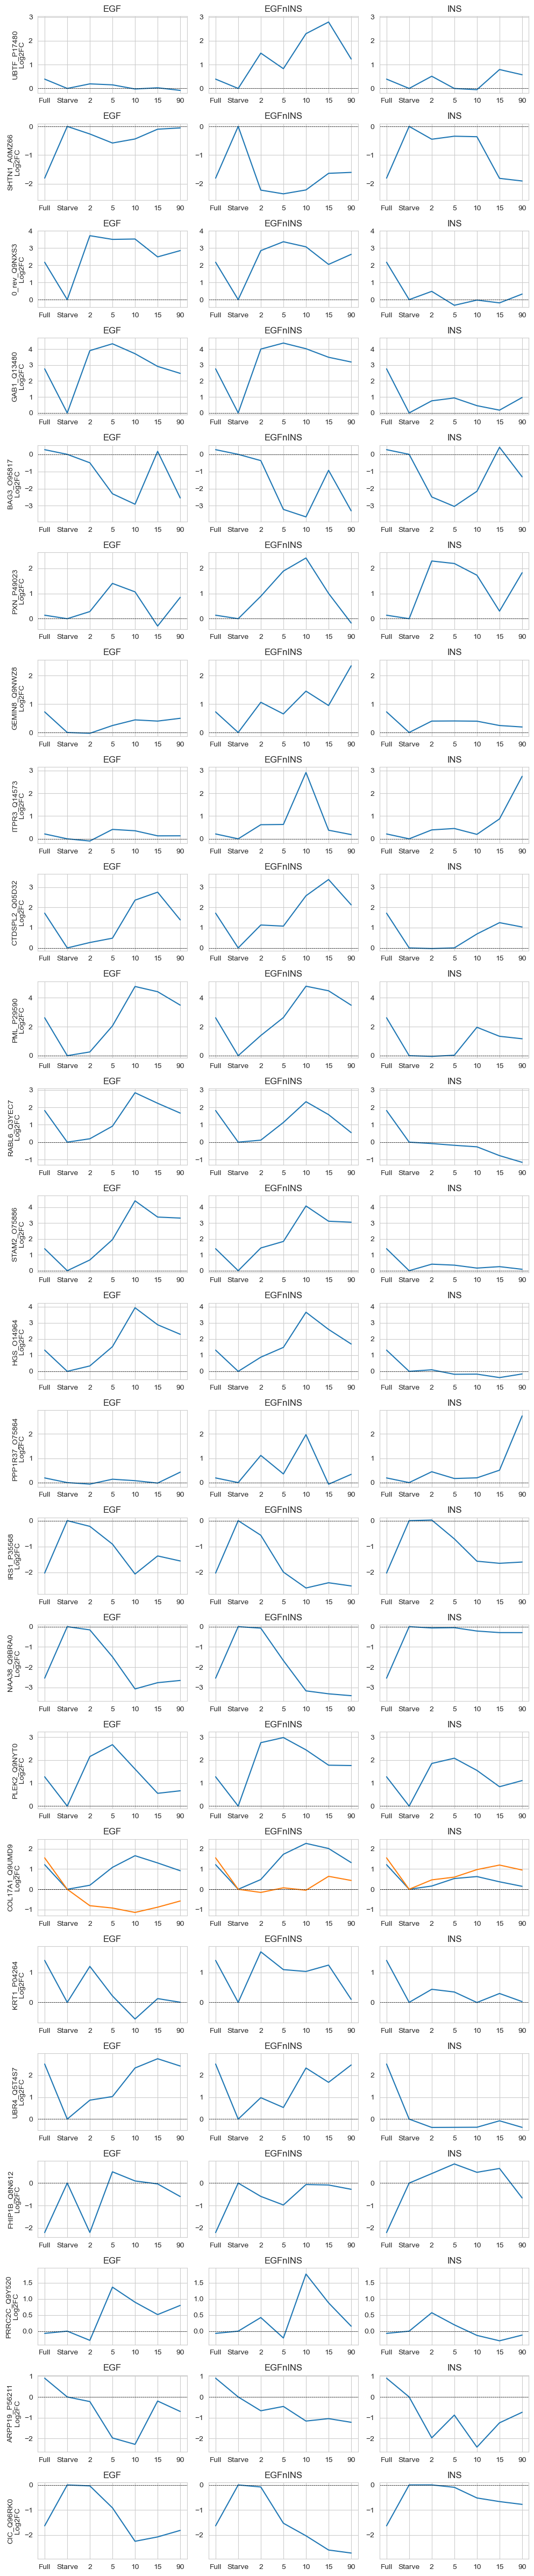

In [24]:
#Dataframe subset
subset = df[df["difference_geometric_mean"] > 0.5] #min_diff, protein_total_diff, difference_geometric_mean

subset_sorted = subset.sort_values(by=['difference_geometric_mean'], ascending=False)

subset_sorted_top = subset_sorted.head(25)

protein_list = subset_sorted_top.protein_name.unique()
print(protein_list)
# protein_list = ['']
plot_protein_profile(subset_sorted_top, experiment= "2_hTERT_HME1" , proteins = protein_list,
                     saving_path = "", saving_info= "",
                     legend = False,
                     save_pdf=False, save_png=False)

# ["AKT2", 'RAF1', 'IGF1R', 'EGFR', 'MAPK3', 'MAP3K1']

 Plot not saved


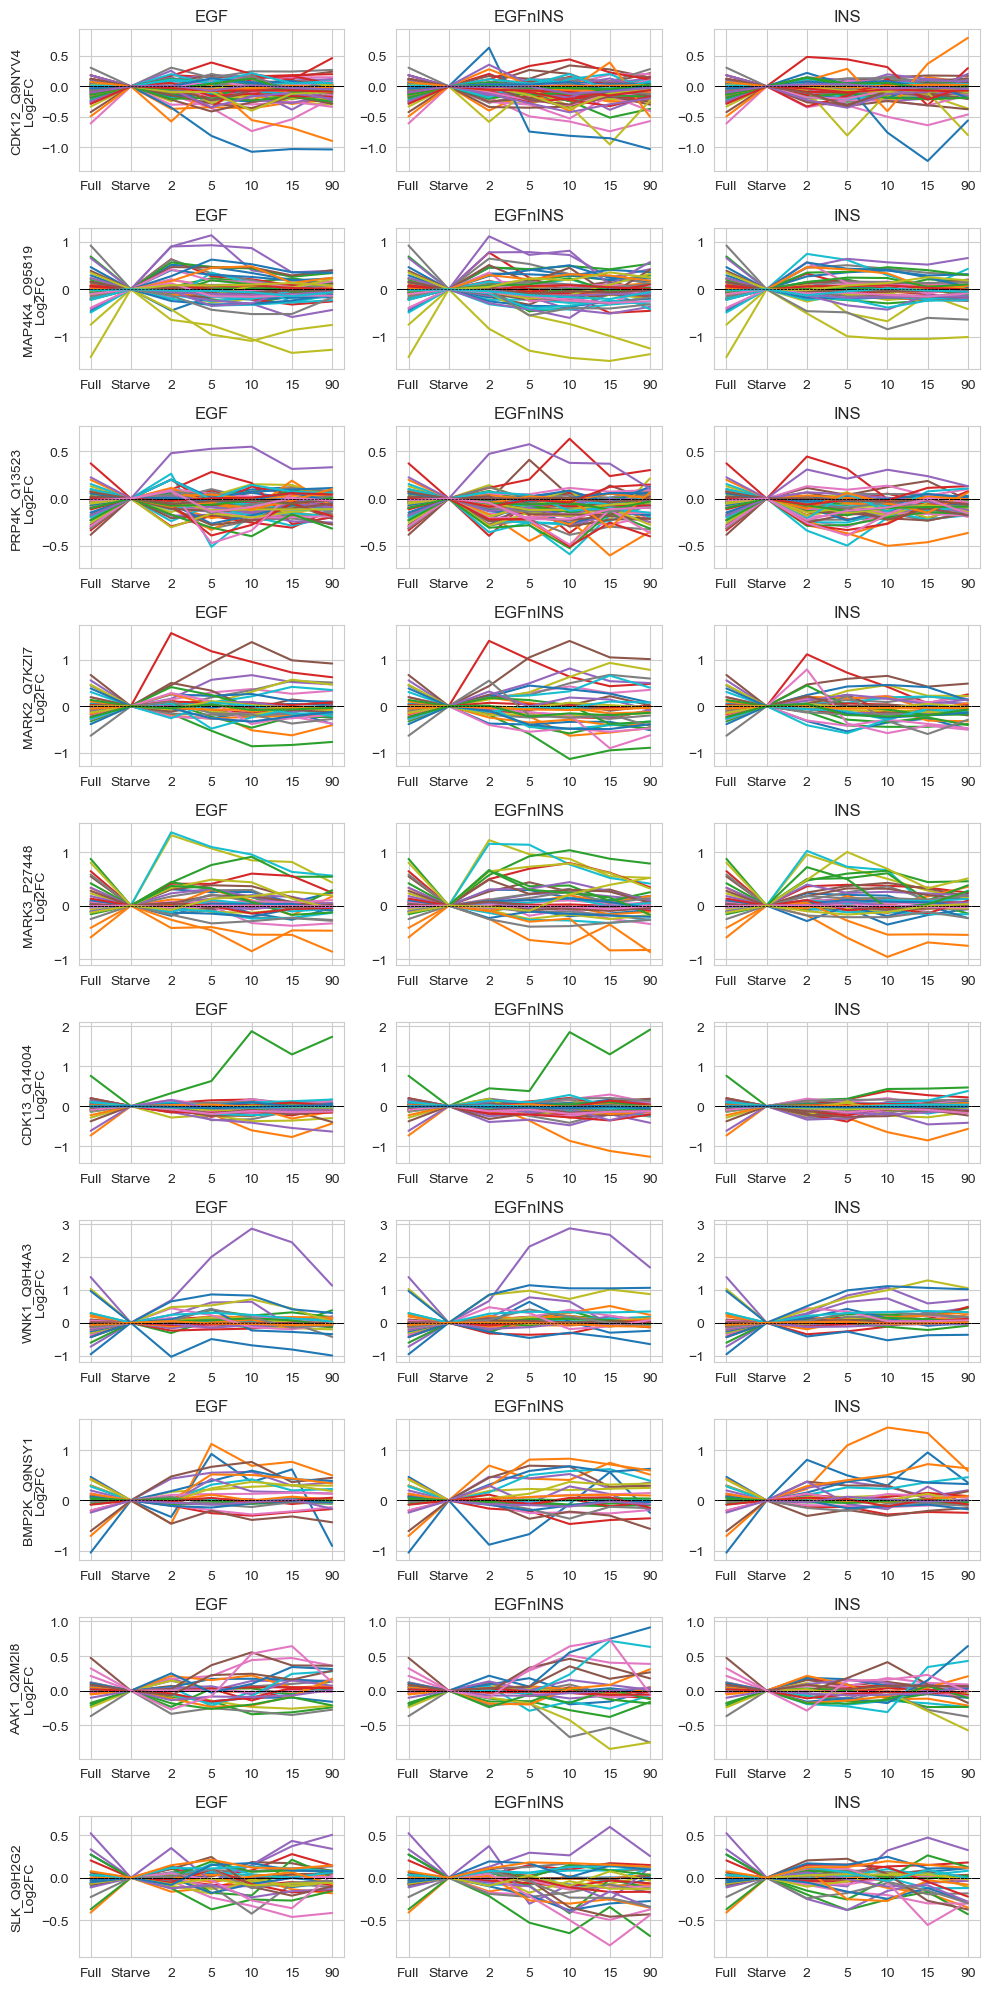

In [157]:
# Checking proteins with the most change between conditions
prot_subset = df_for_kinases[["protein_Id", "protein_total_diff"]]
prot_subset_unique = prot_subset.drop_duplicates()
prot_subset_unique_sorted = prot_subset_unique.sort_values(by=['protein_total_diff'], ascending=False)
top_different_protfile_proteins = list(prot_subset_unique_sorted.protein_Id.head(10))
# top_different_protfile_proteins

# df_filtered = df.loc[df["n_rep"]>1]

plot_protein_profile(df, experiment= "2_hTERT_HME1" , proteins = top_different_protfile_proteins,
                     saving_path = "", saving_info= "",
                     legend = False,
                     save_pdf=False, save_png=False)

Number of common elements: 52
Common elements: ['A0MZ66_381_386_1_1_S384~SHPsGSGAK', 'O15061_592_592_1_1_S592~AEVsPK', 'O60343_588_591_1_1_S591~LGSVDsFER', 'O75864_586_612_3_3_T588S591S597~AEPPASPtPPsPPPPPsPPASPSLPPAGAIDTR', 'O94826_85_110_1_1_S91~KTPEGRAsPAPGSGHPEGPGAHLDMNSLDR', 'O95817_171_191_1_0~SQSPAASDCSSSSSSASLPSSGR', 'P04264_604_612_1_1_S608~GSGGGsSGGSIGGR', 'P13646_421_427_1_0~MIGFPSSAGSVSPR', 'P13646_421_427_1_1_S427~MIGFPSSAGSVsPR', 'P17480_193_208_1_1_T201~SDIPEKPKtPQQLWYTHEK', 'P21397_88_89_2_2_T88Y89~ELGIEtyK', 'P35568_329_351_1_1_S348~ASSDGEGTMSRPASVDGSPVsPSTNR', 'P49023_302_303_2_2_S302S303~ssPGGQDEGGFMAQGK', 'P49750_1649_1650_1_1_S1649~DIsTNK', 'P54727_155_172_2_0~PAEKPAETPVATSPTATDSTSGDSSR', 'P56211_104_108_1_0~KPSLVASK', 'Q00341_944_944_1_1_S944~DCDPGsPR;DCDPGsPRR', 'Q05519_304_310_3_0~SRSTSKTR', 'Q05D32_9_17_1_0~KASQQSNQIQTQR', 'Q12791_1188_1200_1_0~ASLSHSSHSSQSSSK', 'Q13427_587_590_1_1_S587~sKEYHR', 'Q14573_916_930_1_1_S916~sIQGVGHMMSTMVLSR', 'Q14684_451_460_1_0~VA

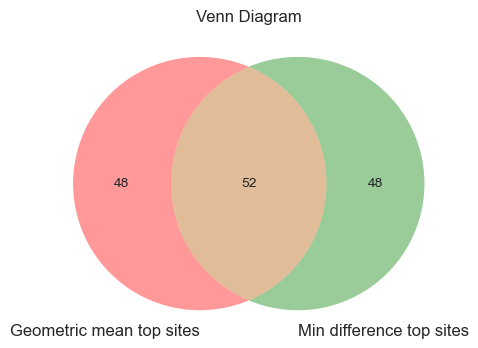

In [15]:
from matplotlib import pyplot as plt
from matplotlib_venn import venn2
# Compare geometric_mean and min_diff
# geometric mean
gm_subset = df[df["difference_geometric_mean"] > 1]
# gm_subset_sorted = gm_subset.sort_values(by=['difference_geometric_mean'], ascending=False)
# gm_top_sites = list(gm_subset_sorted.site.unique())
gm_subset_sorted_top = gm_subset.sort_values(by=['difference_geometric_mean'], ascending=False).head(100)
gm_top_sites_top = list(gm_subset_sorted_top.site.unique())


# min diff
md_subset = df[df["min_diff"] > 1]
# md_subset_sorted = md_subset.sort_values(by=['min_diff'], ascending=False)
# md_top_sites = list(gm_subset_sorted.site.unique())
md_subset_sorted_top = md_subset.sort_values(by=['min_diff'], ascending=False).head(100)
md_top_sites_top = list(md_subset_sorted_top.site.unique())

# #Do comparison
# #Convert lists to sets
# set1 = set(gm_top_sites)
set1 = set(gm_top_sites_top)
# set2 = set(md_top_sites)
set2 = set(md_top_sites_top)

# Find common elements
common_elements = set1 & set2

# Print results
print(f"Number of common elements: {len(common_elements)}")
print(f"Common elements: {sorted(common_elements)}")

# Create a Venn diagram
plt.figure(figsize=(6, 4))
venn2([set1, set2], set_labels=('Geometric mean top sites', 'Min difference top sites'))
plt.title("Venn Diagram")
plt.show()


# Code to plot simplifyed protein profiles

In [194]:
# import data
# df = pd.read_excel("Experiment/1_HEK293T/Data/Processed/Full_dataset_HEK293T_diff.xlsx")
# df = pd.read_excel("Experiment/1_HEK293T/Data/Processed/Full_dataset_HEK293T_diff.xlsx")
# df = pd.read_excel("Experiment/1_HEK293T/Data/Processed/Full_dataset_HEK293T_diff.xlsx")
df = pd.read_excel('Experiment/1_hTERT_HME1/Data/Processed/Full_dataset_1_hTERT_HME1_diff.xlsx')
df = df.fillna(0)
df


,protein_Id,protein_name,site,abs_EGF_full_r1,abs_EGF_full_r2,abs_EGF_full_r3,abs_EGF_full_r4,abs_EGF_starve_r1,abs_EGF_starve_r2,abs_EGF_starve_r3,...,CV_raw_EGFnINS_starve,CV_raw_EGFnINS1,CV_raw_EGFnINS2,CV_raw_EGFnINS5,CV_raw_EGFnINS10,CV_raw_EGFnINS90,CV_raw_All,difference_EGF_vs_EGFnINS,difference_INS_vs_EGFnINS,difference_geometric_mean
0,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_152_154_1_0~SGSGNFGGGR,0.000000e+00,3.413601e+04,0.000000e+00,0.000000e+00,0.000000,11970.095745,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45.495271,0.961789,0.736883,0.841859
1,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_152_154_1_1_S154~SGsGNFGGGR,2.526291e+06,3.107422e+06,2.844213e+06,2.838165e+06,462877.845884,406460.086218,466606.366000,...,12.205152,20.696008,15.790040,8.688666,20.424021,5.861373,77.183414,1.801337,1.559497,1.676061
2,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_260_271_1_0~NQGGYGGSSSSSSYGSGR,2.538396e+05,2.912180e+05,1.878137e+05,2.302995e+05,370294.907420,351169.823470,391574.055743,...,4.626026,9.199745,9.510235,11.659787,23.456764,9.822815,18.609174,0.471713,0.414641,0.442258
3,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_260_271_1_1_S264~NQGGYGGSsSSSSYGSGR,0.000000e+00,3.436628e+04,0.000000e+00,3.184211e+04,0.000000,36947.507319,0.000000,...,17.556007,26.924308,19.852499,38.291377,48.538109,8.717235,26.899678,1.186141,1.430206,1.302469
4,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_260_271_1_1_S266~NQGGYGGSSSsSSYGSGR,4.004880e+05,5.070251e+05,2.948686e+05,0.000000e+00,732858.964004,703950.993495,706990.737660,...,2.222977,7.708196,15.675311,15.772571,19.656534,13.218904,22.851071,0.472098,0.296726,0.374278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34997,Q9Y6Y0,IVNS1ABP,Q9Y6Y0_336_338_1_1_S338~SLsFEMQQDELIEK,3.612031e+04,3.523211e+04,2.328310e+04,2.882678e+04,28158.918559,31337.999945,38445.424548,...,13.174961,3.261711,8.840158,11.748886,16.269093,4.782342,14.703598,0.218582,0.496006,0.329269
34998,Q9Y6Y0,IVNS1ABP,Q9Y6Y0_336_356_1_0~SLSFEMQQDELIEKPMSPMQYAR,0.000000e+00,0.000000e+00,0.000000e+00,1.989511e+04,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.073232,0.721415,0.581098,0.647466
34999,Q9Y6Y0,IVNS1ABP,Q9Y6Y0_336_356_1_1_S338~SLsFEMQQDELIEKPMSPMQYAR,2.252726e+05,2.548493e+05,1.697470e+05,1.780225e+05,202512.144807,165807.326109,237987.604392,...,18.950531,10.566809,16.164894,9.825485,23.560264,12.615745,15.579371,0.294116,0.153964,0.212798
35000,Q9Y6Y8,SEC23IP,Q9Y6Y8_118_138_1_0~PLTALPFTTGSQDVSNAFSPSISK,0.000000e+00,0.000000e+00,3.689021e+03,0.000000e+00,0.000000,0.000000,5253.875296,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.159015,1.186760,0.806254,0.978177


In [196]:
# Filter data
# Filtering only "FC_" columns, excluding those with "statistics"
fc_columns = [col for col in df.columns if col.startswith("FC_") and "stats" not in col.lower() and "pvalue" not in col.lower() and "fdr" not in col.lower()]

# df = df.loc[df["localized_sites"] > 0]
df = df.loc[df["n_rep"] > 1]
# df = df.loc[df["n_reps"] > 1]
#
# fc_columns = list(df.columns)
# fc_columns.remove("protein_ID")
# fc_columns.remove("prot_name")
# fc_columns.remove("site")
# fc_columns.remove("n_reps")
# print(fc_columns)

# Apply filtering condition on selected columns
subset = df[fc_columns]
# subset = subset.head(5).copy()

row_max = subset.max(axis=1)
row_min = subset.min(axis=1)

mask_extremes = (row_max > 0.5) | (row_min < -0.5)

# Step 4: Filter rows into two DataFrames
df_over_05 = df[mask_extremes]
df_below_05 = df[~mask_extremes]

print(len(df), len(df_over_05), len(df_below_05), (len(df_over_05) + len(df_below_05)))

25209 7081 18128 25209


 Plot not saved


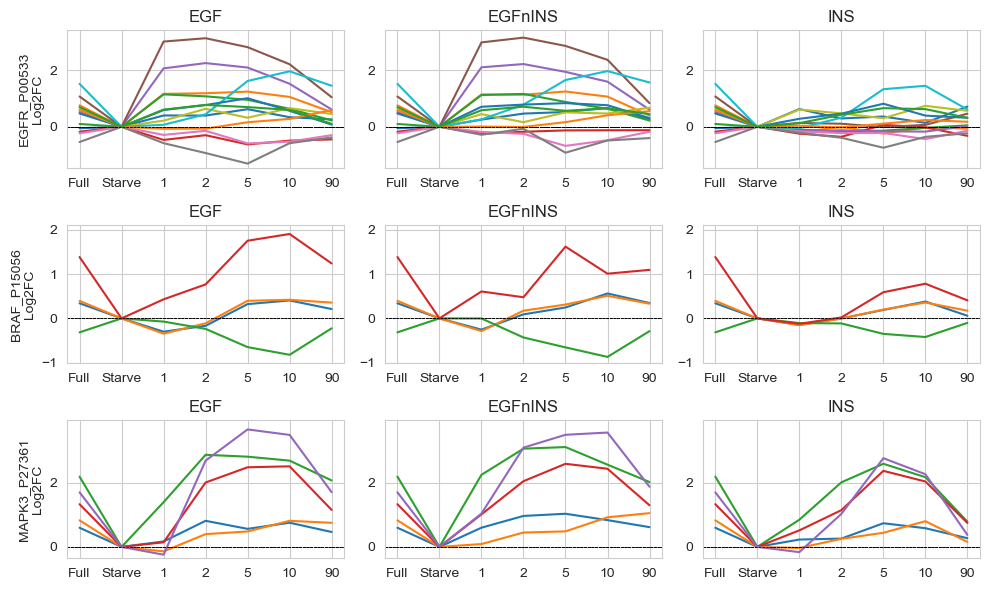

In [197]:
#plot protein profiles
plot_protein_profile(df=df_over_05, experiment="1_hTERT_HME1",
                     proteins = ['EGFR', 'BRAF', 'MAPK3'],
                     saving_path= "", saving_info="",
                     legend="",
                     save_pdf=False, save_png=False)

# Q9C086_INO80B
# CERT1

I have to add the difference value to the big dataframe, to order that, do subdataframe and the plot only those site to not have too much over information


In [2]:
df_diff = pd.read_excel("Experiment/2_hTERT_HME1/Data/Processed/Full_dataset_2_hTERT_HME1_diff_renamed.xlsx")
df_diff

,protein_Id,description,protein_name,Peptide,MaxPepProbability,site_start,site_end,n_sites,localized_sites,phospho_sites,...,CV_raw_EGFnINS_starve,CV_raw_EGFnINS_2,CV_raw_EGFnINS_5,CV_raw_EGFnINS_10,CV_raw_EGFnINS_15,CV_raw_EGFnINS_90,CV_raw_All,difference_EGF_vs_EGFnINS_,difference_INS_vs_EGFnINS_,difference_geometric_mean
0,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGSGNFGGGR,0.9956,197,199,1,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,33.346090,0.644357,0.274540,0.420597
1,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SGsGNFGGGR,1.0000,197,199,1,1,S199,...,18.757996,26.165101,1.230777,12.588830,22.938866,25.170515,50.670048,2.434020,1.123635,1.653768
2,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,SKSEsPKEPEQLR,1.0000,2,6,1,1,S6,...,11.127109,2.641531,3.917276,5.877727,6.619161,2.665032,10.012151,0.255705,0.459264,0.342689
3,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,sKsESPK,0.9894,2,6,2,2,S2;S4,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,33.437045,0.277106,0.671679,0.431424
4,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-lik...,HNRNPA1L3,NQGGYGGSSSSSSYGSGR;NQGGYGGSSSSSSYGSGRRF,1.0000,305,316,1,0,0,...,2.917751,8.674894,9.209089,5.233678,18.339542,5.388291,13.267868,0.295146,0.411714,0.348591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50009,rev_Q5VWT5,0,0,GALMNRRGtHVNtMQIK,0.9898,303,307,2,2,T303;T307,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.475756,0.105879,0.085024,0.094880
50010,rev_Q8N6M0,0,0,LQDEIAKYMCHGDsPIQK,0.9970,135,141,1,1,S141,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.985616,0.139221,0.087091,0.110113
50011,rev_Q96M83,0,0,ERGPtIKK,0.9835,505,505,1,1,T505,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.585989,0.450723,0.196474,0.297582
50012,rev_Q9ULL1,0,0,SSASSSTSGFSVPR,0.9787,1366,1376,2,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.384036,0.196891,0.163787,0.179578


In [3]:
df = pd.read_excel("Experiment/2_hTERT_HME1/Data/Processed/Full_dataset_2_hTERT_HME1_diff.xlsx")
df2 = pd.read_excel("Experiment/2_hTERT_HME1/Data/Processed/Full_dataset_2_hTERT_HME1.xlsx")
# df.loc[df['protein_name', 'site', 'difference_EGF_vs_EGFnINS', 'difference_INS_vs_EGFnINS', "difference_geometric_mean"]]

In [4]:
df_cut = df.loc[500:1000, :]


In [54]:
print(df['site'].head(10))


0                    A0A2R8Y4L2_197_199_1_0~SGSGNFGGGR
1               A0A2R8Y4L2_197_199_1_1_S199~SGsGNFGGGR
2                  A0A2R8Y4L2_2_6_1_1_S6~SKSEsPKEPEQLR
3                      A0A2R8Y4L2_2_6_2_2_S2S4~sKsESPK
4    A0A2R8Y4L2_305_316_1_0~NQGGYGGSSSSSSYGSGR;NQGG...
5       A0A2R8Y4L2_305_316_1_1_S309~NQGGYGGSsSSSSYGSGR
6       A0A2R8Y4L2_305_316_1_1_S312~NQGGYGGSSSSsSYGSGR
7       A0A2R8Y4L2_305_316_1_1_S313~NQGGYGGSSSSSsYGSGR
8       A0A2R8Y4L2_305_316_1_1_S316~NQGGYGGSSSSSSYGsGR
9       A0A2R8Y4L2_305_316_1_1_Y314~NQGGYGGSSSSSSyGSGR
Name: site, dtype: object


In [59]:

print(df['site'].tolist())

['A0A2R8Y4L2_197_199_1_0~SGSGNFGGGR', 'A0A2R8Y4L2_197_199_1_1_S199~SGsGNFGGGR', 'A0A2R8Y4L2_2_6_1_1_S6~SKSEsPKEPEQLR', 'A0A2R8Y4L2_2_6_2_2_S2S4~sKsESPK', 'A0A2R8Y4L2_305_316_1_0~NQGGYGGSSSSSSYGSGR;NQGGYGGSSSSSSYGSGRRF', 'A0A2R8Y4L2_305_316_1_1_S309~NQGGYGGSsSSSSYGSGR', 'A0A2R8Y4L2_305_316_1_1_S312~NQGGYGGSSSSsSYGSGR', 'A0A2R8Y4L2_305_316_1_1_S313~NQGGYGGSSSSSsYGSGR', 'A0A2R8Y4L2_305_316_1_1_S316~NQGGYGGSSSSSSYGsGR', 'A0A2R8Y4L2_305_316_1_1_Y314~NQGGYGGSSSSSSyGSGR', 'A0A2R8Y4L2_4_6_1_0~SESPKEPEQLR', 'A0A2R8Y4L2_4_6_1_1_S4~sESPKEPEQLR', 'A0A2R8Y4L2_4_6_1_1_S6~SEsPKEPEQLRK', 'A0A3B3IU46_36_45_1_0~RPPESPPIVEEWNSR', 'A0A3B3IU46_36_45_1_1_S36~RPPEsPPIVEEWNSR', 'A0AVK6_396_396_1_1_S396~HPsLIK', 'A0AVK6_413_417_2_0~KINSAPSSPIK', 'A0AVK6_413_417_2_2_S416S417~KINSAPssPIK', 'A0AVK6_52_60_1_1_T58~EGSQGEPWtPTANLK', 'A0AVK6_660_664_1_1_S664~ENSSALsPNHR', 'A0AVK6_68_71_1_1_S71~MLISAVsPEIR', 'A0FGR8_676_678_1_1_S676~RPsVSK', 'A0FGR8_688_711_1_0~SHMSGSPGPGGSNTAPSTPVIGGSDKPGMEEK', 'A0FGR8_688_711_1_1_S6